In [69]:
# import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
# Load csv file
df = pd.read_csv(r'C:\Users\Sirmoi Wekesa\Downloads\bank_transactions_messy.csv')
# looking at first 5 rows
df.head()
df

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Date,Account_Balance,Branch,Fraud_Flag
0,17270,1059,6373.892985294444,Transfer,01/02/2024,11407.668579035788,NaN,0
1,10860,1042,3401.0033336730266,Withdrawal,2024/03/01,6558.971838175865,NaN,0
2,15390,1075,4526.001657879679,Transfer,2024-01-01,17874.21372011432,NaN,0
3,15191,1099,4794.31167372786,PAYMENT,2024/03/01,24508.913752125147,Mombasa,0
4,15734,1067,4184.353827862911,Withdrawal,01/02/2024,30548.590692108868,Mombasa,0
...,...,...,...,...,...,...,...,...
1045,14289,1048,5595.842130519605,payment,2024-01-01,8628.212241974397,Kisumu,0
1046,12336,1048,2575.085442301545,Deposit,01/02/2024,29469.284683570564,Mombasa,0
1047,10466,1036,7006.102619322368,Withdrawal,01/02/2024,15152.093236431068,Nairobi,0
1048,11976,1083,8536.596616793544,PAYMENT,2024/03/01,26569.471123242787,NaN,0


In [71]:
#show column types and missing values
df.info()
#overall infor for all columns
df.describe(include = 'all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Transaction_ID      1050 non-null   int64 
 1   Customer_ID         1050 non-null   int64 
 2   Transaction_Amount  1048 non-null   object
 3   Transaction_Type    1050 non-null   object
 4   Transaction_Date    1050 non-null   object
 5   Account_Balance     1050 non-null   object
 6   Branch              787 non-null    object
 7   Fraud_Flag          1050 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 65.8+ KB


,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Date,Account_Balance,Branch,Fraud_Flag
count,1050.000000,1050.000000,1048,1050,1050,1050,787,1050.000000
unique,NaN,NaN,598,5,4,626,3,NaN
top,NaN,NaN,5663.943467906965,Transfer,2024/03/01,31222.035676977153,Kisumu,NaN
freq,NaN,NaN,6,219,279,5,266,NaN
mean,14990.500000,1049.409524,NaN,NaN,NaN,NaN,NaN,0.044762
std,2823.229987,29.136638,NaN,NaN,NaN,NaN,NaN,0.206879
min,10004.000000,1000.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,12552.500000,1025.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,15138.000000,1048.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,17339.000000,1075.000000,NaN,NaN,NaN,NaN,NaN,0.000000


In [72]:
# CHECKING DATA QUALITY ISSUES
#1. counting missing values 
df.isnull().sum()

Transaction_ID          0
Customer_ID             0
Transaction_Amount      2
Transaction_Type        0
Transaction_Date        0
Account_Balance         0
Branch                263
Fraud_Flag              0
dtype: int64

In [73]:
#2. counting duplicated rows
df.duplicated().sum()

np.int64(50)

In [74]:
#3. check inconsistent categories
df['Transaction_Type'].value_counts()

Transaction_Type
Transfer      219
PAYMENT       217
Withdrawal    210
Deposit       208
payment       196
Name: count, dtype: int64

In [75]:
#4. check for weired values in amount column
df['Transaction_Amount'].unique()[:10]

array(['6373.892985294444', '3401.0033336730266', '4526.001657879679',
       '4794.31167372786', '4184.353827862911', '5871.111696749626',
       '7006.102619322368', '3579.0949003300966', '5732.914332595944',
       '5312.7562458365555'], dtype=object)

In [76]:
#since transaction amount column is an object, we must convert to numeric
df['Transaction_Amount'] = pd.to_numeric(df['Transaction_Amount'], errors = 'coerce')

#convert account balance column to numeric
df['Account_Balance'] = pd.to_numeric(df['Account_Balance'], errors = 'coerce')

# Convert Transaction_Date column to date-time format
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors = 'coerce')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      1050 non-null   int64         
 1   Customer_ID         1050 non-null   int64         
 2   Transaction_Amount  1046 non-null   float64       
 3   Transaction_Type    1050 non-null   object        
 4   Transaction_Date    265 non-null    datetime64[ns]
 5   Account_Balance     1049 non-null   float64       
 6   Branch              787 non-null    object        
 7   Fraud_Flag          1050 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 65.8+ KB


In [77]:
# Handling missing values
# Find and replace missing values in transaction amount column with median
df['Transaction_Amount'] = df['Transaction_Amount'].fillna(df['Transaction_Amount'].median())

# Find and replace missing values in Account_Balance column with median
df['Account_Balance'] = df['Account_Balance'].fillna(df['Account_Balance'].median ())

#Replace missing branch names with 'Unknown'
df['Branch'] = df['Branch'].fillna('Unknown')

In [78]:
df.describe(include = 'all')

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Date,Account_Balance,Branch,Fraud_Flag
count,1050.000000,1050.000000,1050.000000,1050,265,1050.000000,1050,1050.000000
unique,NaN,NaN,NaN,5,NaN,NaN,4,NaN
top,NaN,NaN,NaN,Transfer,NaN,NaN,Kisumu,NaN
freq,NaN,NaN,NaN,219,NaN,NaN,266,NaN
mean,14990.500000,1049.409524,7882.829537,NaN,2024-01-02 00:00:00,19791.028368,NaN,0.044762
min,10004.000000,1000.000000,-1703.221034,NaN,2024-01-02 00:00:00,-9044.643966,NaN,0.000000
25%,12552.500000,1025.000000,3632.812400,NaN,2024-01-02 00:00:00,12845.394565,NaN,0.000000
50%,15138.000000,1048.000000,5166.345900,NaN,2024-01-02 00:00:00,19327.704378,NaN,0.000000
75%,17339.000000,1075.000000,6503.480547,NaN,2024-01-02 00:00:00,26789.771856,NaN,0.000000
max,19998.000000,1099.000000,999999.000000,NaN,2024-01-02 00:00:00,46376.948880,NaN,1.000000


In [79]:
# dropping duplicates

df = df.drop_duplicates()
df

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Date,Account_Balance,Branch,Fraud_Flag
0,17270,1059,6373.892985,Transfer,2024-01-02,11407.668579,Unknown,0
1,10860,1042,3401.003334,Withdrawal,NaT,6558.971838,Unknown,0
2,15390,1075,4526.001658,Transfer,NaT,17874.213720,Unknown,0
3,15191,1099,4794.311674,PAYMENT,NaT,24508.913752,Mombasa,0
4,15734,1067,4184.353828,Withdrawal,2024-01-02,30548.590692,Mombasa,0
...,...,...,...,...,...,...,...,...
995,18554,1087,9424.382619,Withdrawal,NaT,21056.538250,Nairobi,0
996,12443,1042,5553.418088,Transfer,NaT,31511.294060,Unknown,0
997,17783,1097,4397.489529,Transfer,2024-01-02,35101.106799,Nairobi,0
998,10984,1088,3287.386861,Deposit,NaT,38272.615050,Kisumu,0


In [80]:
# Standardize text
# converting all standard types to lower case and removing spaces
df.loc[:, 'Transaction_Type'] = df['Transaction_Type'].str.lower().str.strip()

In [81]:
# Removing unrealistic values
# Removing negative transaction amounts
df = df[df['Transaction_Amount'] > 0]

#Removing extremely large transaction amount
df = df[df['Transaction_Amount'] < 100000]

In [82]:
# Feature engineering. Creating useful columns for analysis
#Extract day
df['day'] = df['Transaction_Date'].dt.day

#Extracting month
df['month'] = df['Transaction_Date'].dt.month

# Flagging high value transactions
df['High_Value'] = df['Transaction_Amount'] > 100000

In [83]:
# calculating mean transaction amount
mean_transaction_amount = df['Transaction_Amount'].mean()

#Calculating the variance/spread of the data
transaction_amount_var = df['Transaction_Amount'].var()

print(mean_transaction_amount)
print(transaction_amount_var)

5065.616170018392
3668865.935402503


In [84]:
#Estimating the true average transaction
import scipy.stats as stats  # statistical functions

# take random sample of 100 transactions
sample = df['Transaction_Amount'].sample(100)

# compute sample mean
mean = sample.mean()

# standard error of the mean
sem = stats.sem(sample)

# compute 95% confidence interval
ci = stats.t.interval(0.95, len(sample)-1, loc=mean, scale=sem)

ci

(np.float64(4726.496286013364), np.float64(5561.582204800725))

In [86]:
# Finding patterns in data
# average transaction amount by fraud status
df.groupby('Fraud_Flag')['Transaction_Amount'].mean()

# Fraud rate by transaction type
df.groupby('Transaction_Type')['Fraud_Flag'].mean()

# fraud rate for high-value transactions
df.groupby('High_Value')['Fraud_Flag'].mean()



High_Value
False    0.047379
Name: Fraud_Flag, dtype: float64

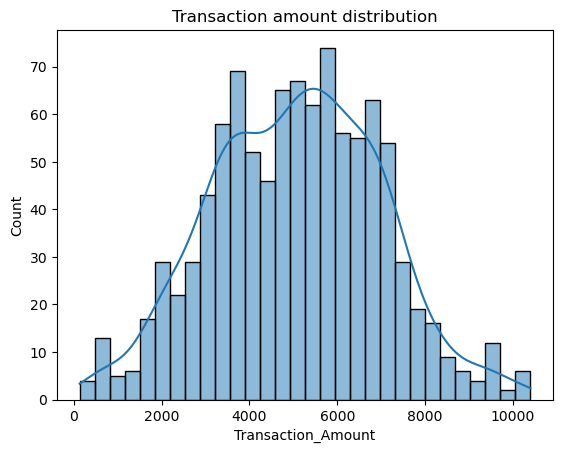

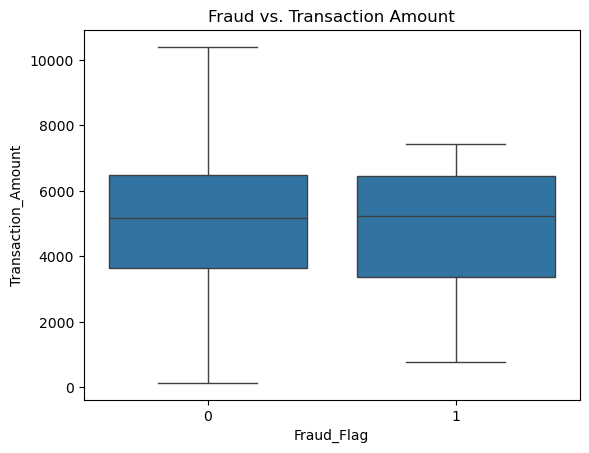

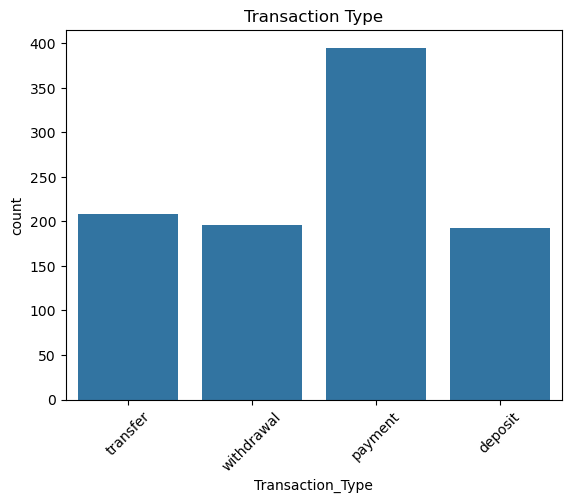

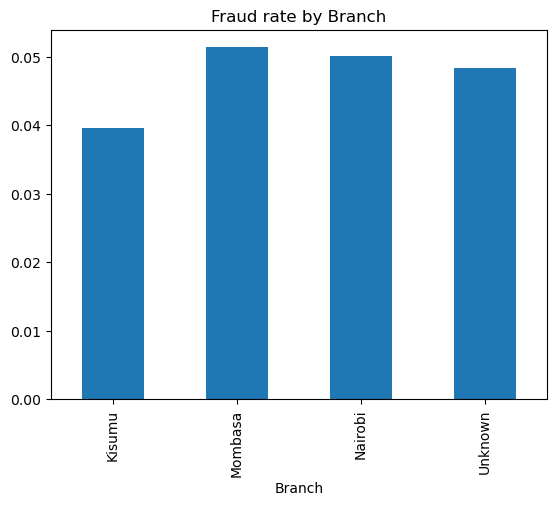

In [91]:
# VISUALIZATIONS
# Distribution of transaction amount
sns.histplot(df['Transaction_Amount'], bins = 30, kde = True)
plt.title('Transaction amount distribution')
plt.show()

#comparison; Fraud vs. nonfraud
sns.boxplot(x = 'Fraud_Flag', y = 'Transaction_Amount', data = df)
plt.title('Fraud vs. Transaction Amount')
plt.show()

# Transaction count by type
sns.countplot(x = 'Transaction_Type', data = df)
plt.xticks(rotation = 45)
plt.title('Transaction Type')
plt.show()

#Fraud rate by branch
fraud_rate = df.groupby('Branch')['Fraud_Flag'].mean()
fraud_rate.plot(kind = 'bar')
plt.title('Fraud rate by Branch')
plt.show()

In [ ]:
# Setting basic fraud detection rule
